# Red Neuronal — Enfermedad de Carrión (MINSA 2000–2024)

Clasificación de la **fase** de la enfermedad de Carrión: `AGUDA` (0) vs
`ERUPTIVA` (1), con una red neuronal Keras `5 → 32 → 32 → 1` (la misma
arquitectura del notebook del Titanic).

Se usa la **misma fuente de datos y las mismas 5 features** que el Árbol de
Decisión, para poder comparar ambos modelos de forma justa.

## 1. Librerías, carga y preprocesamiento

Mismo preprocesamiento que el Árbol de Decisión (misma fuente de datos).

In [1]:
import pandas as pd
import numpy as np
training = pd.read_csv("comparador-ml/data/carrion-train.csv")

DEPARTAMENTOS = ["AMAZONAS","ANCASH","APURIMAC","AYACUCHO","CAJAMARCA","CUSCO",
 "HUANUCO","JUNIN","LA LIBERTAD","LAMBAYEQUE","LIMA","LORETO","MADRE DE DIOS",
 "PASCO","PIURA","PUNO","SAN MARTIN","TACNA","UCAYALI"]
depto_idx = {d: i for i, d in enumerate(DEPARTAMENTOS)}
columns = ["edad_anios", "sexo_cod", "depto_cod", "ano", "semana"]

def edad_anios(e, t):
    t = str(t).upper()
    return e/12 if t == "M" else (e/365 if t == "D" else float(e))

def preparar(df):
    df = df[df["enfermedad"].isin(["ENFERMEDAD DE CARRION AGUDA",
                                   "ENFERMEDAD DE CARRION ERUPTIVA"])].copy()
    df["edad_anios"] = df.apply(lambda r: edad_anios(r["edad"], r["tipo_edad"]), axis=1)
    df["sexo_cod"]   = df["sexo"].apply(lambda s: 0 if str(s).upper() == "M" else 1)
    df["depto_cod"]  = df["departamento"].apply(lambda d: depto_idx[str(d).upper()])
    df["target"]     = df["enfermedad"].map({"ENFERMEDAD DE CARRION AGUDA": 0,
                                             "ENFERMEDAD DE CARRION ERUPTIVA": 1})
    return df[columns].values.astype(float), df["target"].values

x_input, y_target = preparar(training)
print("x_input:", x_input.shape, " y_target:", y_target.shape)

x_input: (36896, 5)  y_target: (36896,)


## 2. Normalización min-max

Las features tienen rangos muy distintos (año ~2000, semana 1–53, edad 0–99).
A diferencia del Titanic, aquí normalizamos al rango [0, 1] para que la red
converja mejor. Los mismos `min`/`max` se reutilizan en el conjunto de prueba.

In [2]:
x_min = x_input.min(axis=0)
x_max = x_input.max(axis=0)
rango = np.where((x_max - x_min) == 0, 1, x_max - x_min)
x_input_n = (x_input - x_min) / rango
print("min:", x_min)
print("max:", x_max)

min: [0.e+00 0.e+00 0.e+00 2.e+03 1.e+00]
max: [9.900e+01 1.000e+00 1.800e+01 2.024e+03 5.300e+01]


## 3. Definir y entrenar la red neuronal

In [3]:
import keras
from keras import layers
model = keras.Sequential()
model.add(layers.Dense(32, input_dim=5, activation='relu'))
model.add(layers.Dense(32, activation='relu', name='layer1'))
model.add(layers.Dense(1, activation='sigmoid', name='layer2'))
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

C:\Users\Usuario\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [4]:
# batch_size=256 porque el dataset es grande (~37k filas); el Titanic (915) no lo necesitaba.
model.fit(x_input_n, y_target, epochs=400, batch_size=256, verbose=0)
score = model.evaluate(x_input_n, y_target, verbose=0)
print("%s: %.2f%%" % (model.metrics_names[1], score[1]*100))

compile_metrics: 72.22%


Predicción individual de ejemplo (se normaliza con los mismos min/max).

In [5]:
caso = np.array([[20.0, 0, 1, 2004, 31]])      # edad, sexo, depto, ano, semana
caso_n = (caso - x_min) / rango
respuesta = model.predict(caso_n, verbose=0)
print("prob ERUPTIVA:", float(respuesta[0][0]), "=>", respuesta.round()[0][0])

prob ERUPTIVA: 0.40873417258262634 => 0.0


## 4. Métricas sobre el entrenamiento

Matriz de Confusion:
 [[21337  3345]
 [ 6906  5308]]
Metricas:
               precision    recall  f1-score   support

       AGUDA       0.76      0.86      0.81     24682
    ERUPTIVA       0.61      0.43      0.51     12214

    accuracy                           0.72     36896
   macro avg       0.68      0.65      0.66     36896
weighted avg       0.71      0.72      0.71     36896



C:\Users\Usuario\AppData\Local\Temp\ipykernel_1648\1812671822.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + labels); ax.set_yticklabels([''] + labels)
C:\Users\Usuario\AppData\Local\Temp\ipykernel_1648\1812671822.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + labels); ax.set_yticklabels([''] + labels)


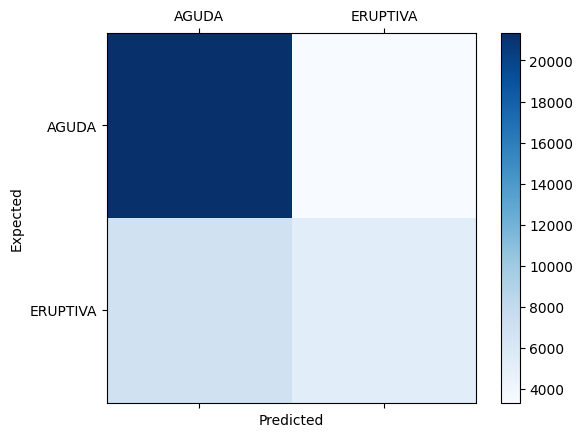

In [6]:
from sklearn.metrics import confusion_matrix, classification_report
from matplotlib import pyplot as plt
y_sim = (model.predict(x_input_n, verbose=0).ravel() >= 0.5).astype(int)
conf_mat = confusion_matrix(y_true=y_target, y_pred=y_sim)
print('Matriz de Confusion:\n', conf_mat)
print('Metricas:\n', classification_report(y_target, y_sim, target_names=["AGUDA","ERUPTIVA"]))
labels = ['AGUDA', 'ERUPTIVA']
fig = plt.figure(); ax = fig.add_subplot(111)
cax = ax.matshow(conf_mat, cmap=plt.cm.Blues); fig.colorbar(cax)
ax.set_xticklabels([''] + labels); ax.set_yticklabels([''] + labels)
plt.xlabel('Predicted'); plt.ylabel('Expected'); plt.show()

In [7]:
# especificidad
VN = conf_mat[1,1]; FP = conf_mat[0,1]
especificidad = VN / (VN + FP)
print("Especificidad:", especificidad)

Especificidad: 0.6134288686004854


## 5. Guardar y cargar el modelo (Keras)

In [8]:
model_json = model.to_json()
with open("mimodelocarrion.json", "w") as json_file:
    json_file.write(model_json)
model.save_weights("mimodelocarrion.weights.h5")
print("modelo guardado")

modelo guardado


In [9]:
from keras.models import model_from_json
with open("mimodelocarrion.json", "r") as json_file:
    loaded_model = model_from_json(json_file.read())
loaded_model.load_weights("mimodelocarrion.weights.h5")
loaded_model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
print("modelo cargado en el disco")

modelo cargado en el disco


## 6. Evaluación con el conjunto de prueba

In [10]:
testing = pd.read_csv("comparador-ml/data/carrion-test.csv")
x_test, y_test = preparar(testing)
x_test_n = (x_test - x_min) / rango          # mismos min/max del entrenamiento
score_test = loaded_model.evaluate(x_test_n, y_test, verbose=0)
print("Accuracy prueba: %.2f%%" % (score_test[1]*100))

Accuracy prueba: 71.75%


## 7. Interpretación y comparación

A diferencia del Árbol de Decisión (que memoriza el entrenamiento y generaliza
peor), la Red Neuronal con datos normalizados ofrece un desempeño **estable**
entre entrenamiento y prueba. En el informe se contrastan ambas estrategias
—reglas explícitas del árbol vs. pesos distribuidos de la red— sobre el mismo
conjunto de datos de vigilancia del MINSA.